# 1. Business Problem

### A telecommunication company wants to reduce customer churn. The company has historical customer information and knows whether each customer eventually Left(Churn=Yes) or Stayed(Churn=No).

## The objective is:

### Build a model that predicts the probability that a customer will Churn allowing the Company to identify high risk customers and take retention actions before they leave.



In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Telco_Churn_Dataset.csv')

In [ ]:
# Preview
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Dataset size
df.shape

(7043, 21)

In [ ]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### **Data Cleaning**

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors= 'coerce'
)

In [ ]:
# Recheck missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Remove the missing values
df = df.dropna()

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove the customer ID column
df = df.drop('customerID', axis=1)  #Not useful for prediciting Churn

### **Explore the target variable**

In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


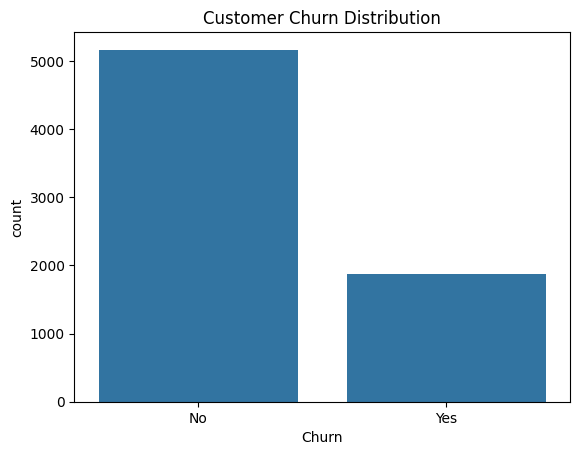

In [ ]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

**Class Distribution**


1.   No(Non-churners) : 73.4%
2.   Yes(Churners) : 26.4%



### Explore Churn against important variables

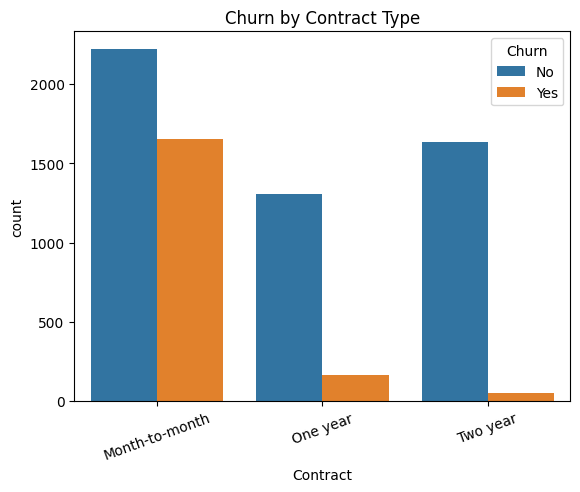

In [ ]:
# Contract type
sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Churn by Contract Type')
plt.xticks(rotation=20)
plt.show()

## Customers on month-to-month contracts churn much more frequently than customers on longer contracts.

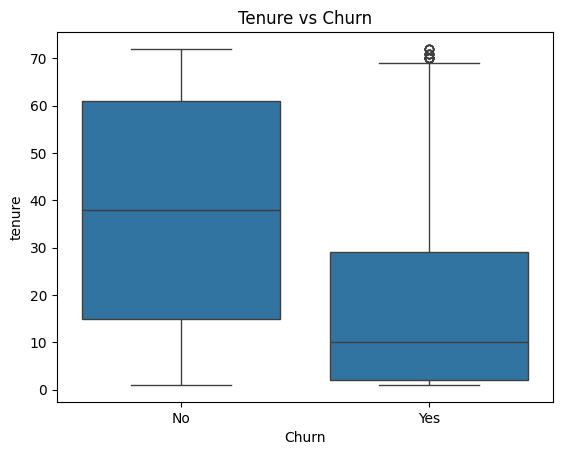

In [ ]:
# Tenure
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

**Clients who leave tend to have shorter relationship with the company.**

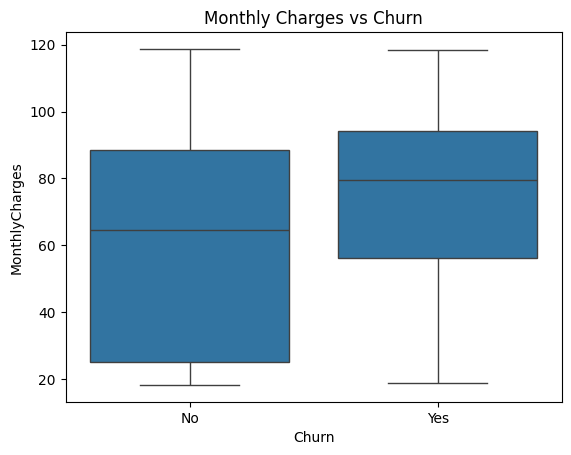

In [ ]:
# Monthly Charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

**Customers paying higher monthly charges are more likely to leave.**

## **Prepare the target variable**
### Machine learning algorithms do not understand Yes/No

### So we convert them into binary: 1 or 0

In [ ]:
df['Churn'] = df['Churn'].map(
    {
        'Yes': 1,
        'No': 0
    }
)

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


**## Separate Features(X) and Target(y)**


In [ ]:
# Features
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

**# Convert categorical columns**

In [ ]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [ ]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)  # 80% training 20% test

**## random_state=42 - allows for reproducibility**

**## stratify = y to maintain approximately the same churn/non-churn proportion in both datasets**

## **Scale the numerical Features**
### **Logistic regression works better when the numerical variables are on comparable scales.**

### **For example**
### **tenure 1-72**

### **monthlycharges 20-120**

### **totalcharges 20-8000**

### **The scales are very different**

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training
X_train_scaled = scaler.fit_transform(X_train)

# Transform
X_test_scaled = scaler.transform(X_test)

**We use fit_transform() on training data and transform() on test data because we don't want the training data influencing the test data.**
**Prevent data leakages.**

**Train Logistic Regression**

In [ ]:
# Initialize the model
model = LogisticRegression(max_iter=1000)

# fit
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Customer characteristics

          ↓

   Logistic Regression

          ↓
Probability of churn

          ↓
          
   0 or 1 prediction


### **Make Predictions**

In [ ]:
# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:,1]   # returns probability of Churn

# Convert probabilities to class labels
y_pred = (y_prob > 0.3).astype(int)

# Threshold = 0.3
# If probability >= 0.3 -> Churn

### **Model Evaluation**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy * 100)

Accuracy: 74.34257285003554


In [ ]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



1. The model identifies most customers at risk of churn

Using a 30% churn-probability threshold, the model achieved a 76% recall for churners. This means the model can identify approximately three-quarters of customers who actually churned.

Business implication: The company can use the model as an early-warning system to identify customers who may need retention intervention.

2. The lower threshold prioritizes retention

The model classifies a customer as high-risk when their predicted probability of churn is 30% or higher, rather than using the conventional 50% threshold.

Business implication: This approach favors catching more potential churners, even though it means some customers who would have stayed will also be targeted.

3. There is a trade-off between catching churners and targeting unnecessary customers

The model achieved 51% precision for churn. Therefore, not every customer identified as high-risk will actually churn.

Business implication: The company should not automatically give discounts to every predicted churner. Instead, it could use additional criteria such as customer value, tenure, monthly revenue, or cost of retention to decide who receives an offer.

4. Accuracy alone is not sufficient

The model achieved approximately 74.3% accuracy, but accuracy does not tell the full business story. Since the objective is to reduce customer loss, recall for the churn class is particularly important.

5. Recommended business action

The telecom company could create a customer-risk list from the model:

High risk: churn probability ≥ 70%
Medium risk: 30–69%
Low risk: < 30%

High-value customers in the high-risk group could receive personalized retention offers, proactive customer support, or contract incentives.

## **Confusion Matrix**

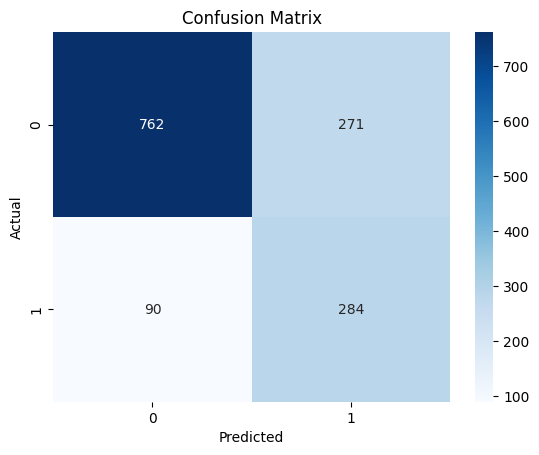

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **762 - True Negatives -> Customers that our model correctly predicted would stay**

### **90 - False Negative -> Customers who actually churned but our model incorrectly predicted would stay**

### **271 - False Positives -> Customers who actually stayed but our model incorrectly predicted they would Churn**

### **284 - True Positives -> Customers that our model correctly predicted would Churn**

### **ROC-AUC**

In [ ]:
auc = roc_auc_score(y_test, y_prob)

print('AUC:', auc )

AUC: 0.8356727976766699


**0.84 which is good -- meaning the model distinguishes between Churn vs No-Churn**

**ROC-CURVE**

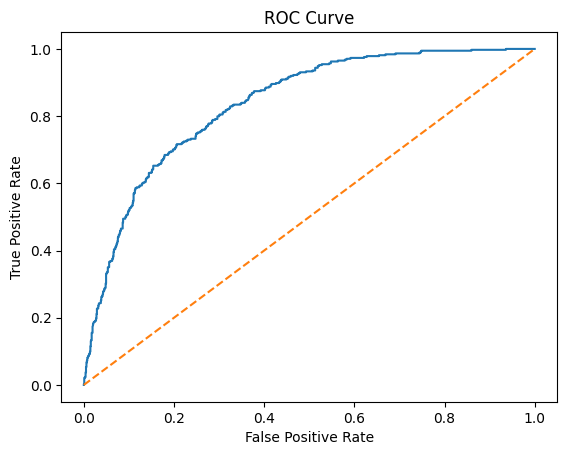

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

The ROC curve is well above the diagonal reference line, showing that the logistic regression model can distinguish between customers who are likely to churn and those who are likely to stay substantially better than random guessing.

## Understand which factors influence churn

In [ ]:
coefficients = pd.DataFrame(
    {
        'Feature': X.columns,
        'Coefficient': model.coef_[0]
    }
)

coefficients = coefficients.sort_values('Coefficient', ascending=False)

coefficients.head(10)
# associated with highest probability of churn

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


### **A positive coeffcient means:**
### **a higher value of this feature is associated with a higher probability of churn**


In [ ]:
coefficients.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
2,MonthlyCharges,-0.851551
1,tenure,-1.347613


### **A negative coefficient means:**
### **a higher value/presence of this feature is associated with a lower probability of churn**